In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bisect
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler

# プロジェクトルートをパスに追加
sys.path.insert(0, '/Users/nishiharahiroto/Documents/programs/market-analytics-ver1')
from data.utils.database_manager import DatabaseManager

# 定数定義
TARGET_TENORS = ['3M', '6M', '9M', '1Y', '2Y', '3Y', '5Y', '7Y']
D = 0.4
WINDOW = 50
OOS_START = '2024-01-01'

# 出力ディレクトリ（フォルダ作成のみ維持）
OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")


In [2]:
db = DatabaseManager()

# OIS データ（product_type='OIS'）
rows = db.get_ois_data(product_type='OIS')
df_swap_raw = pd.DataFrame(rows)
df_swap_raw['trade_date'] = pd.to_datetime(df_swap_raw['trade_date'])

# ワイド形式に変換（index=trade_date, columns=tenor）
df_ois = df_swap_raw.pivot(index='trade_date', columns='tenor', values='rate')

# 7Y以下のテナーのみ残す
df_ois = df_ois[[t for t in TARGET_TENORS if t in df_ois.columns]]
df_ois = df_ois.sort_index()

# FX
fx_q = "SELECT trade_date, currency_pair, close_price FROM exchange_rates WHERE currency_pair IN ('USDJPY', 'DXY')"
df_fx = pd.DataFrame(db.select_as_dict(fx_q))
df_fx['trade_date'] = pd.to_datetime(df_fx['trade_date'])
df_fx = df_fx.pivot(index='trade_date', columns='currency_pair', values='close_price')

# 日経
nk_q = "SELECT trade_date, close_price as nikkei FROM stock_prices WHERE ticker = '^N225'"
df_nk = pd.DataFrame(db.select_as_dict(nk_q))
df_nk['trade_date'] = pd.to_datetime(df_nk['trade_date'])
df_nk = df_nk.set_index('trade_date')[['nikkei']]

# 米国10年金利
us_q = "SELECT trade_date, yield_value as ust10y FROM foreign_yields WHERE region = 'US' AND tenor = '10Y'"
df_us = pd.DataFrame(db.select_as_dict(us_q))
df_us['trade_date'] = pd.to_datetime(df_us['trade_date'])
df_us = df_us.set_index('trade_date')[['ust10y']]

# 日銀会合データ
boj_q = "SELECT meeting_date, policy_rate_after as policy_rate FROM boj_meetings ORDER BY meeting_date"
df_boj = pd.DataFrame(db.select_as_dict(boj_q))
df_boj['meeting_date'] = pd.to_datetime(df_boj['meeting_date'])
df_boj['policy_rate'] = df_boj['policy_rate'].astype(float)

print(f"OIS data range: {df_ois.index.min()} to {df_ois.index.max()}")


INFO:data.utils.database_manager:DatabaseManager initialized for ep-calm-boat-a1zzrjkt-pooler.ap-southeast-1.aws.neon.tech


OIS data range: 2014-06-23 00:00:00 to 2026-03-27 00:00:00


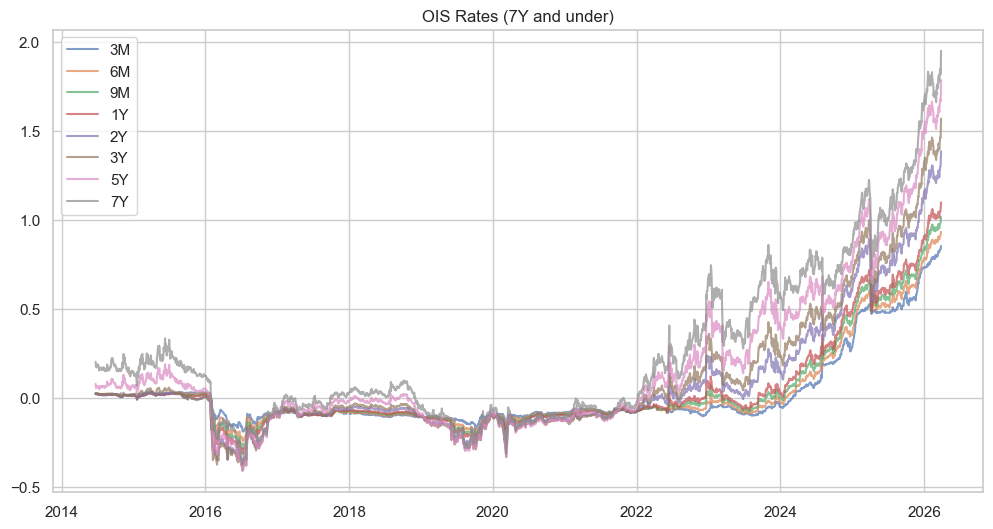

Missing rates (%) :
tenor
3M    4.558107
6M    3.479471
9M    3.166319
1Y    0.139179
2Y    0.069589
3Y    0.034795
5Y    0.000000
7Y    0.000000
dtype: float64


In [3]:
plt.figure(figsize=(12, 6))
for tenor in df_ois.columns:
    plt.plot(df_ois.index, df_ois[tenor], label=tenor, alpha=0.7)
plt.title("OIS Rates (7Y and under)")
plt.legend()
plt.show()

print("Missing rates (%) :")
print(df_ois.isna().mean() * 100)


In [4]:
# OIS + マクロを outer join で結合
df_all = df_ois.join([df_fx, df_nk, df_us], how='outer')
df_all = df_all.sort_index()

# 全行NaNは除去
df_all = df_all.dropna(how='all')

# 数値型へ
for col in df_all.columns:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# 補完フラグを先に立てる（補完前に必ず実行）
numeric_cols = [c for c in df_all.columns if not c.endswith('_is_imputed')]
for col in numeric_cols:
    df_all[f'{col}_is_imputed'] = df_all[col].isna().astype(int)

# MICE補完（スケーリング → 補完 → 逆スケーリング）
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_all[numeric_cols]),
    columns=numeric_cols, index=df_all.index
)
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)
df_imputed_scaled = imputer.fit_transform(df_scaled)
df_all[numeric_cols] = scaler.inverse_transform(df_imputed_scaled)

print("Imputation completed.")


Imputation completed.


/Users/nishiharahiroto/Documents/programs/market-analytics-ver1/venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [5]:
# 全取引日のインデックスに policy_rate を forward fill でマージ
df_boj_daily = df_boj.set_index('meeting_date')[['policy_rate']]
df_boj_daily = df_boj_daily.reindex(df_all.index, method='ffill')

# days_to_next_mpm: 次回会合日までの営業日数
meeting_dates = df_boj['meeting_date'].sort_values().values
def days_to_next(date, meeting_dates):
    future = meeting_dates[meeting_dates > date]
    if len(future) == 0:
        return np.nan
    return (future[0] - date).days

df_all['policy_rate'] = df_boj_daily['policy_rate']
df_all['days_to_next_mpm'] = [days_to_next(d, meeting_dates) for d in df_all.index]

# MPM直後フラグ（学習・評価除外用）
df_all['is_meeting_day'] = df_all.index.isin(df_boj['meeting_date']).astype(int)
df_all['is_post_mpm'] = (
    df_all['is_meeting_day'].rolling(window=6, min_periods=1).max()
).astype(int)

print("BOJ features generated.")


BOJ features generated.


In [6]:
def frac_diff(series: pd.Series, d: float = 0.4, window: int = 50) -> pd.Series:
    weights = [1.0]
    for k in range(1, window):
        weights.append(-weights[-1] * (d - k + 1) / k)
    weights = np.array(weights[::-1])

    arr = series.to_numpy(dtype=float)
    n = len(arr)
    result = np.full(n, np.nan)
    if n < window:
        return pd.Series(result, index=series.index)

    from numpy.lib.stride_tricks import sliding_window_view
    windows_view = sliding_window_view(arr, window_shape=window)
    dots = windows_view @ weights
    dots[np.isnan(windows_view).any(axis=1)] = np.nan
    result[window - 1:] = dots
    return pd.Series(result, index=series.index)

def tenor_to_float(t: str) -> float:
    num = float(''.join(filter(str.isdigit, t)))
    return num / 12.0 if 'M' in t else num

MACRO_COLS = ['USDJPY', 'DXY', 'nikkei', 'ust10y']
OIS_COLS   = [t for t in TARGET_TENORS if t in df_all.columns]

def build_pooled_df(df_all: pd.DataFrame, ois_cols: list, macro_cols: list, h: int) -> pd.DataFrame:
    macro_fd = {}
    for m in macro_cols:
        if m in df_all.columns:
            macro_fd[f'{m}_fd'] = frac_diff(df_all[m], D, WINDOW)

    all_rows = []
    for tenor in ois_cols:
        s = df_all[tenor]

        # 特徴量
        ois_level    = s
        ois_spread_h = s - s.shift(h)
        ois_fd       = frac_diff(s, D, WINDOW)

        # 目的変数
        target = s.shift(-h) - s

        tmp = pd.DataFrame({
            'tenor':             tenor,
            'tenor_val':         tenor_to_float(tenor),
            'ois_level':         ois_level,
            'ois_spread_h':      ois_spread_h,
            'ois_fd':            ois_fd,
            'policy_rate':       df_all.get('policy_rate', pd.Series(np.nan, index=df_all.index)),
            'days_to_next_mpm':  df_all.get('days_to_next_mpm', pd.Series(np.nan, index=df_all.index)),
            'is_post_mpm':       df_all['is_post_mpm'],
            'target':            target,
        }, index=df_all.index)

        for col, series in macro_fd.items():
            tmp[col] = series

        # 補完フラグを追加
        for flag_col in [c for c in df_all.columns if c.endswith('_is_imputed')]:
            tmp[flag_col] = df_all[flag_col]

        all_rows.append(tmp)

    df_long = pd.concat(all_rows).sort_index()
    feat_cols = [c for c in df_long.columns if c not in ('tenor', 'is_post_mpm', 'target')]
    df_long = df_long.dropna(subset=feat_cols + ['target'])
    df_long = df_long[df_long['is_post_mpm'] == 0].drop(columns='is_post_mpm')

    # 正規化
    df_long['target_std'] = df_long.groupby('tenor')['target'].transform('std')
    df_long['target_norm'] = df_long['target'] / df_long['target_std']

    return df_long

df_long_3d = build_pooled_df(df_all, OIS_COLS, MACRO_COLS, 3)
df_long_5d = build_pooled_df(df_all, OIS_COLS, MACRO_COLS, 5)

print(f"df_long_3d shape: {df_long_3d.shape}")


df_long_3d shape: (29704, 26)


Feature stats (3d):


,count,mean,std,min,25%,50%,75%,max
tenor_val,29704.0,2.437500,2.273355,0.250000,0.687500,1.500000,3.500000,7.000000
ois_level,29704.0,0.082723,0.267483,-0.408750,-0.075000,0.025000,0.103750,1.831250
ois_spread_h,29704.0,-0.000262,0.105912,-1.500316,-0.002424,0.000000,0.002500,1.470068
ois_fd,29704.0,0.011971,0.086331,-1.245124,-0.013383,0.003616,0.022083,1.061367
policy_rate,29704.0,0.074199,0.214134,-0.100000,-0.100000,0.100000,0.100000,0.750000
days_to_next_mpm,29704.0,15.835443,11.388432,1.000000,7.000000,14.000000,23.000000,58.000000
target,29704.0,0.000058,0.109075,-1.540451,-0.001751,0.000000,0.002500,1.470068
USDJPY_fd,29704.0,16.039237,3.199588,4.938859,14.192287,15.586526,17.560969,27.710714
DXY_fd,29704.0,13.020063,1.704865,-1.409524,11.913284,13.244709,14.089061,22.699833
nikkei_fd,29704.0,3082.677209,2390.284282,-21726.880155,1826.049845,2896.434942,4101.730145,24440.515000


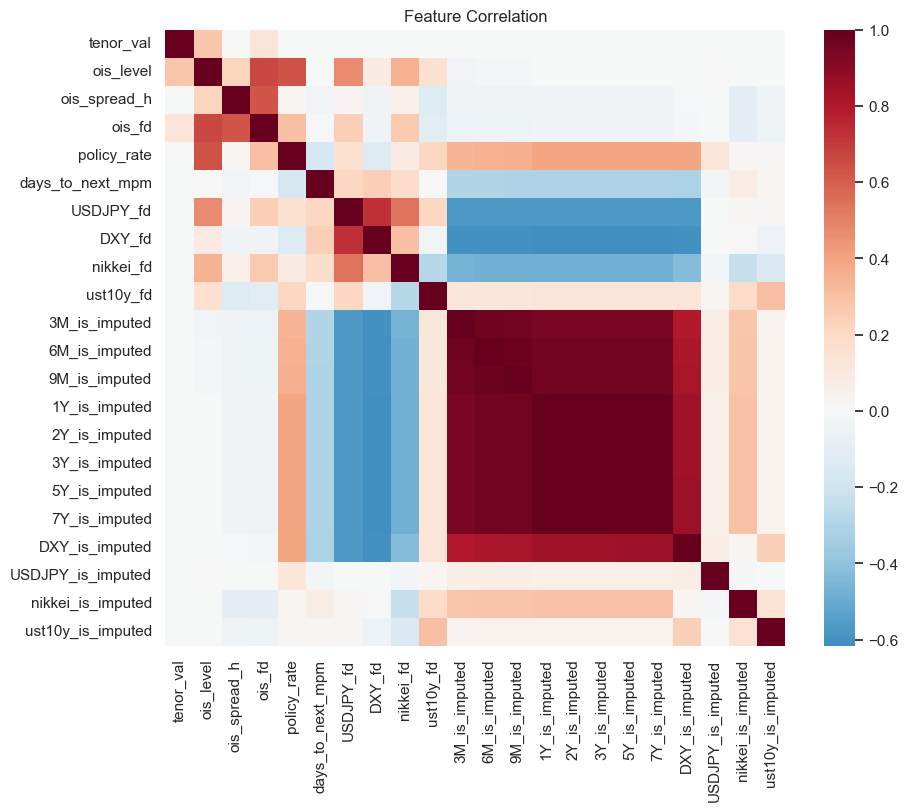

In [7]:
print("Feature stats (3d):")
display(df_long_3d.describe().T)

plt.figure(figsize=(10, 8))
corr_cols = [c for c in df_long_3d.columns if c not in ['tenor', 'target', 'target_std', 'target_norm']]
sns.heatmap(df_long_3d[corr_cols].corr(), 
            cmap='RdBu_r', center=0, annot=False)
plt.title("Feature Correlation")
plt.show()


In [8]:
PARAMS = {
    'objective':       'regression',
    'metric':          'rmse',
    'verbosity':       -1,
    'boosting_type':   'gbdt',
    'random_state':    42,
    'learning_rate':   0.05,
    'num_leaves':      31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':    5,
    'min_data_in_leaf': 30,
    'lambda_l2':       1.0,
}
NUM_BOOST_ROUND = 100
TEST_WINDOW_DAYS = 90
PURGE_DAYS = 5

NON_FEATURE_COLS = {'tenor', 'target', 'target_std', 'target_norm'}

def walk_forward(df_long: pd.DataFrame, oos_start: str) -> pd.DataFrame:
    target_col  = 'target_norm'
    feature_cols = [c for c in df_long.columns if c not in NON_FEATURE_COLS]

    unique_dates = sorted(df_long.index.unique())
    oos_start_dt = pd.to_datetime(oos_start)
    start_idx = bisect.bisect_left(unique_dates, oos_start_dt)

    results = []
    current_idx = start_idx
    fold = 0

    while current_idx < len(unique_dates):
        train_end  = unique_dates[current_idx - 1]
        purge_end  = train_end - pd.Timedelta(days=PURGE_DAYS)
        test_start = unique_dates[current_idx]
        test_end   = test_start + pd.Timedelta(days=TEST_WINDOW_DAYS)

        train_mask = df_long.index <= purge_end
        test_mask  = (df_long.index >= test_start) & (df_long.index < test_end)

        if train_mask.sum() < 100 or test_mask.sum() < 10:
            current_idx = bisect.bisect_left(unique_dates, test_end)
            continue

        X_train = df_long.loc[train_mask, feature_cols]
        y_train = df_long.loc[train_mask, target_col]
        X_test  = df_long.loc[test_mask,  feature_cols]
        y_test  = df_long.loc[test_mask,  target_col]

        dtrain = lgb.Dataset(X_train, label=y_train)
        model  = lgb.train(PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)

        preds      = model.predict(X_test)
        train_ic, _ = spearmanr(y_train, model.predict(X_train))

        fold_df = df_long.loc[test_mask, ['tenor', 'target', 'target_std']].copy()
        fold_df['pred_norm'] = preds
        fold_df['pred']      = preds * fold_df['target_std']
        fold_df['actual']    = fold_df['target']
        fold_df['fold']      = fold
        fold_df['train_ic']  = train_ic

        results.append(fold_df)

        fold += 1
        current_idx = bisect.bisect_left(unique_dates, test_end)

    return pd.concat(results).reset_index(names='date') if results else pd.DataFrame()

def summarize_ic(results_df: pd.DataFrame, recent_n_folds: int = 3) -> dict:
    if results_df.empty: return {}
    actual = results_df['actual']
    pred   = results_df['pred_norm']

    ic_all, _ = spearmanr(actual, pred)

    cs_ics = []
    for date, grp in results_df.groupby('date'):
        if len(grp) >= 3:
            ic, _ = spearmanr(grp['actual'], grp['pred_norm'])
            if not np.isnan(ic):
                cs_ics.append(ic)
    cs_ic = np.mean(cs_ics) if cs_ics else np.nan

    ts_ics = []
    for tenor, grp in results_df.groupby('tenor'):
        if len(grp) >= 5:
            ic, _ = spearmanr(grp['actual'], grp['pred_norm'])
            if not np.isnan(ic):
                ts_ics.append(ic)
    ts_ic = np.mean(ts_ics) if ts_ics else np.nan

    unique_folds = sorted(results_df['fold'].unique())
    recent_folds = unique_folds[-recent_n_folds:]
    recent_df    = results_df[results_df['fold'].isin(recent_folds)]
    ic_recent, _ = spearmanr(recent_df['actual'], recent_df['pred_norm'])

    train_ic = results_df.groupby('fold')['train_ic'].first().mean()
    gap      = train_ic - ic_all

    return dict(
        ic_all=ic_all, ic_recent=ic_recent,
        cs_ic=cs_ic, ts_ic=ts_ic,
        train_ic=train_ic, gap=gap,
    )


In [9]:
print("Running Walk-Forward for h=3...")
res_3d = walk_forward(df_long_3d, OOS_START)
if not res_3d.empty:
    stats_3d = summarize_ic(res_3d)
    print(f"3d: Global IC={stats_3d.get('ic_all',0):.3f}, CS IC={stats_3d.get('cs_ic',0):.3f}, TS IC={stats_3d.get('ts_ic',0):.3f}, Gap={stats_3d.get('gap',0):.3f}")
else:
    print("res_3d is empty")
    stats_3d = {}


Running Walk-Forward for h=3...


3d: Global IC=0.193, CS IC=0.010, TS IC=0.200, Gap=0.093


In [10]:
print("Running Walk-Forward for h=5...")
res_5d = walk_forward(df_long_5d, OOS_START)
if not res_5d.empty:
    stats_5d = summarize_ic(res_5d)
    print(f"5d: Global IC={stats_5d.get('ic_all',0):.3f}, CS IC={stats_5d.get('cs_ic',0):.3f}, TS IC={stats_5d.get('ts_ic',0):.3f}, Gap={stats_5d.get('gap',0):.3f}")
else:
    print("res_5d is empty")
    stats_5d = {}


Running Walk-Forward for h=5...


5d: Global IC=0.152, CS IC=-0.022, TS IC=0.165, Gap=0.191


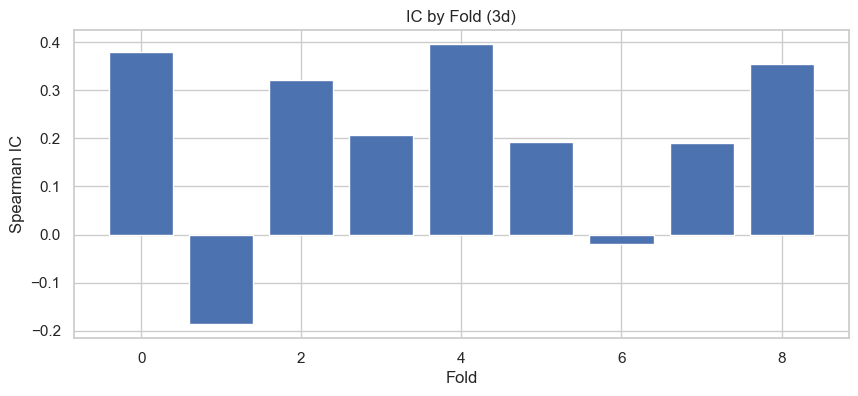

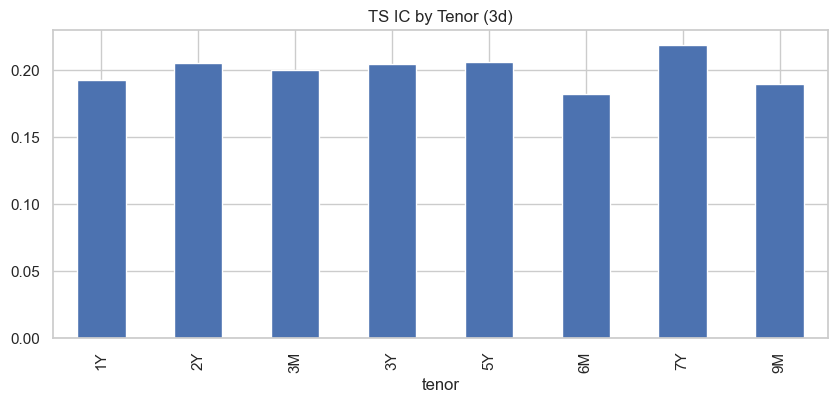

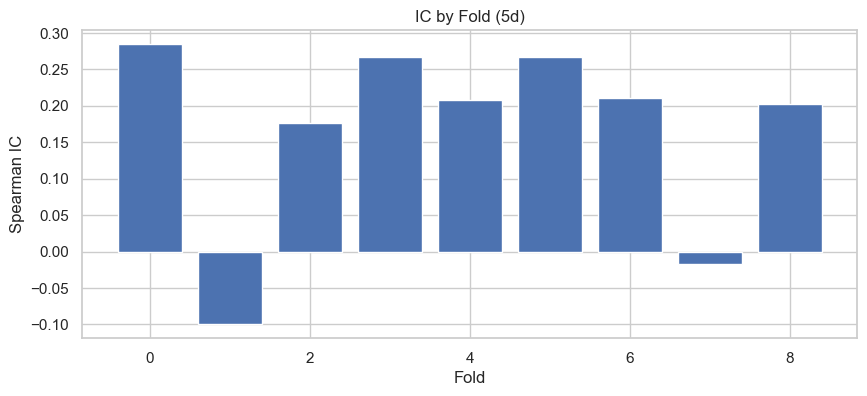

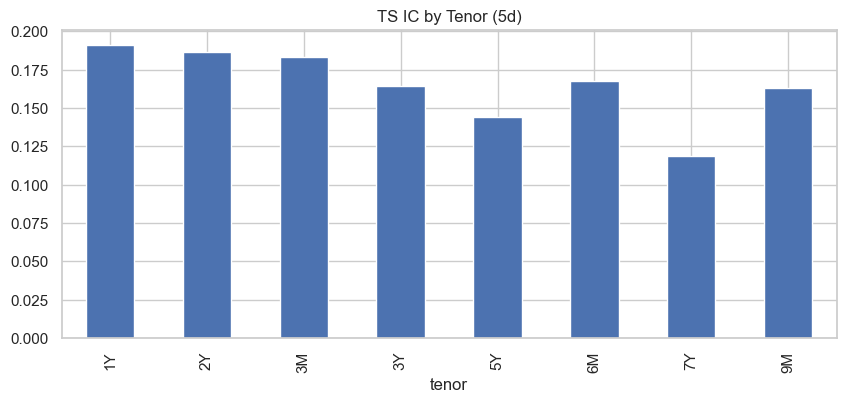

In [11]:
def plot_results(res_df, h_str):
    if res_df.empty:
        print(f"res_{h_str} is empty, skipping plots.")
        return
        
    # IC by fold
    fold_ics = []
    for f in sorted(res_df['fold'].unique()):
        df_f = res_df[res_df['fold'] == f]
        ic, _ = spearmanr(df_f['actual'], df_f['pred_norm'])
        fold_ics.append(ic)
    
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(fold_ics)), fold_ics)
    plt.title(f"IC by Fold ({h_str})")
    plt.xlabel("Fold")
    plt.ylabel("Spearman IC")
    plt.show()

    # IC by tenor
    tenor_ics = res_df.groupby('tenor').apply(lambda x: spearmanr(x['actual'], x['pred_norm'])[0], include_groups=False)
    plt.figure(figsize=(10, 4))
    tenor_ics.plot(kind='bar')
    plt.title(f"TS IC by Tenor ({h_str})")
    plt.show()

plot_results(res_3d, "3d")
plot_results(res_5d, "5d")


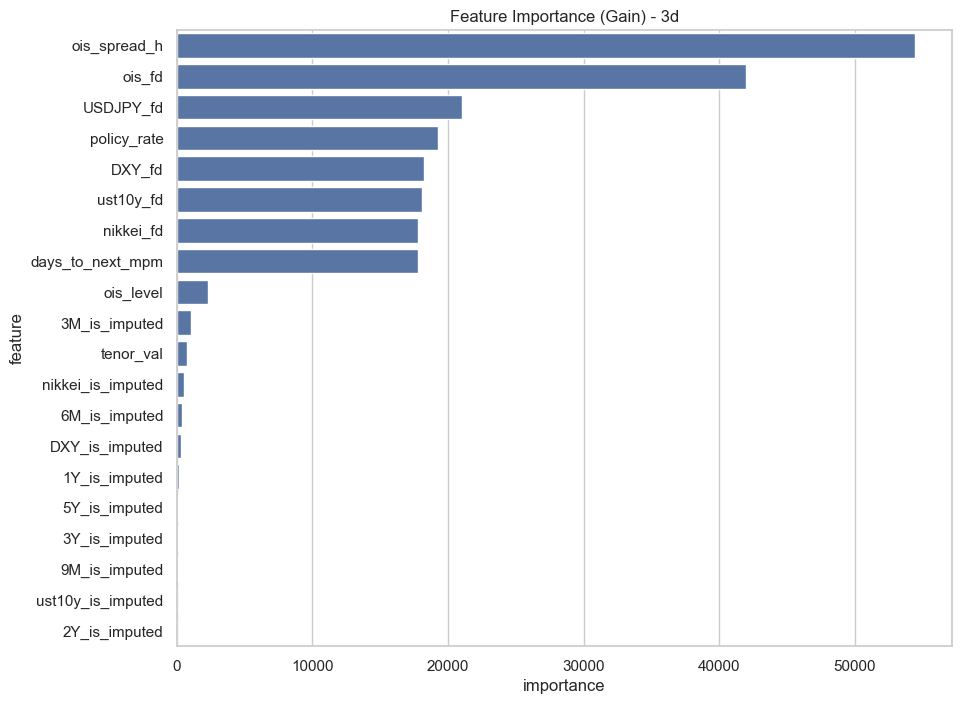

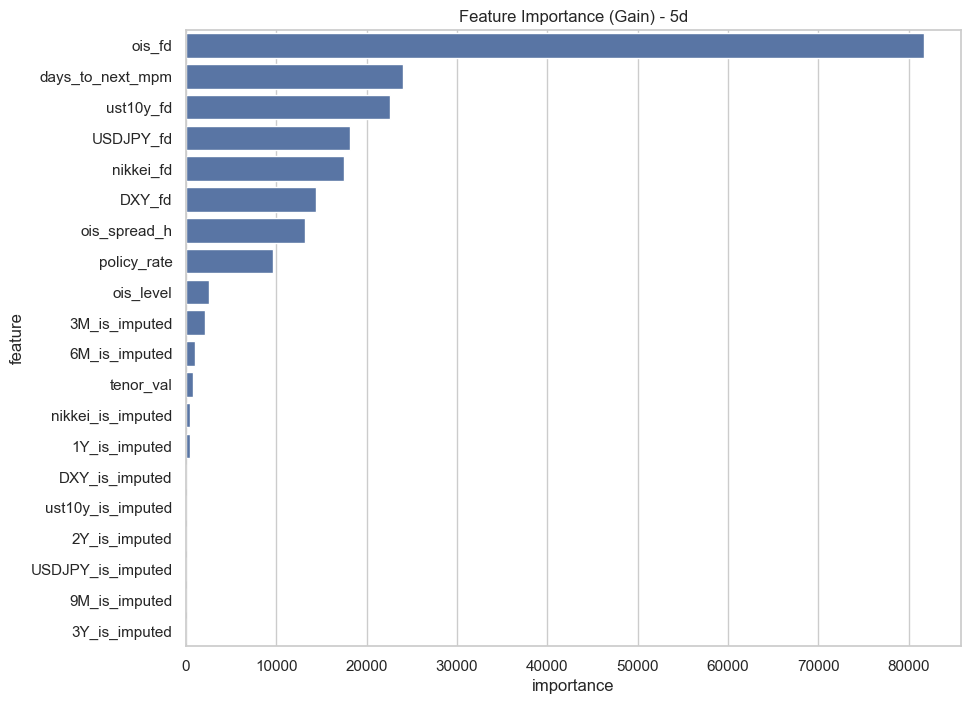

In [12]:
def plot_importance(df_long, h_str):
    if df_long.empty:
        print(f"df_long_{h_str} is empty, skipping importance.")
        return
    feature_cols = [c for c in df_long.columns if c not in NON_FEATURE_COLS]
    X = df_long[feature_cols]
    y = df_long['target_norm']
    
    dtrain = lgb.Dataset(X, label=y)
    model = lgb.train(PARAMS, dtrain, num_boost_round=NUM_BOOST_ROUND)
    
    importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': model.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance.head(20), x='importance', y='feature')
    plt.title(f"Feature Importance (Gain) - {h_str}")
    plt.show()

plot_importance(df_long_3d, "3d")
plot_importance(df_long_5d, "5d")


In [13]:
# Results Summary
summary_text = f"""
モデル名: spot_rate_7y_base
対象テナー: {', '.join(TARGET_TENORS)}
特徴量: ois_level, ois_spread_h, ois_fd, macro_fd, boj_calendar
OOS開始日: {OOS_START}
rounds: {NUM_BOOST_ROUND}

3d: Global IC={stats_3d.get('ic_all',0):.3f}, CS IC={stats_3d.get('cs_ic',0):.3f}, TS IC={stats_3d.get('ts_ic',0):.3f}, Gap={stats_3d.get('gap',0):.3f}, ic_recent={stats_3d.get('ic_recent',0):.3f}
5d: Global IC={stats_5d.get('ic_all',0):.3f}, CS IC={stats_5d.get('cs_ic',0):.3f}, TS IC={stats_5d.get('ts_ic',0):.3f}, Gap={stats_5d.get('gap',0):.3f}, ic_recent={stats_5d.get('ic_recent',0):.3f}
"""
print(summary_text)



モデル名: spot_rate_7y_base
対象テナー: 3M, 6M, 9M, 1Y, 2Y, 3Y, 5Y, 7Y
特徴量: ois_level, ois_spread_h, ois_fd, macro_fd, boj_calendar
OOS開始日: 2024-01-01
rounds: 100

3d: Global IC=0.193, CS IC=0.010, TS IC=0.200, Gap=0.093, ic_recent=0.162
5d: Global IC=0.152, CS IC=-0.022, TS IC=0.165, Gap=0.191, ic_recent=0.158

